In [1]:
import sys
if '/disks/cosmodm/vdvuurst' not in sys.path:
    sys.path.append('/disks/cosmodm/vdvuurst')

import numpy as np
import h5py
from matplotlib import pyplot as plt
import os
from importlib import reload
import json
import ONEHALO
from tqdm import tqdm
from functions import modified_logspace, BIC
from onehalo_plotter import *
from functional_forms import *
format_plot()

from scipy.optimize import minimize

In [2]:
np.random.seed(42)
combi_subsample_idx = np.random.choice(len(all_combis),size = len(all_combis)//100) #1% subsample 
all_combis = np.array(all_combis, dtype=object)
combi_subsample = all_combis[combi_subsample_idx]
combi_subsample_names = np.array(all_names, dtype = object)[combi_subsample_idx]
print(f'There are {combi_subsample.shape[0]} function combinations')

There are 92 function combinations


In [3]:
# n_params_r, n_params_m = jointfitter.fit_to_data(combi_subsample[0])
function_combi = combi_subsample[0]
print(function_combi)

def param_info(function_combi):
    # Generate parameter information lists (pointers) given a function combination
    n_params_r = []
    n_params_m = [] # every list is for a double gauss parameter, containing a number of parameters needed to parametrize an r-parameter in terms of M for every r-parameter
    for i,param_combi in enumerate(function_combi):
        _, m_parametrizations = param_combi # unpack the function combination for this specific parameter
        n_params_r.append(len(m_parametrizations))
        n_params_m.append([len(signature(m_func).parameters) - 1 for m_func in m_parametrizations])

    n_params_m = flatten(n_params_m)

    return n_params_r, n_params_m

n_params_r, n_params_m = param_info(function_combi)

print(f'{n_params_m = }')

nparams = sum(n_params_m)
print(f'Total of {nparams} parameters.')

mbin = 12.25
rbin = 0.035

mass_filepath = '/disks/cosmodm/vdvuurst/data/Onehalo_M_12-15.5_subsampled.hdf5'
with h5py.File(mass_filepath) as handle:
    halo_masses = handle['mass'][:]
    # rel_pos = handle['rel_pos'][:]
    rel_vels = handle['rel_vels'][:]
    rel_dist = handle['rel_dist'][:]
    
Nv, Nmr = rel_vels.size, rel_vels.shape[0]

# np.random.seed(42)
params = np.random.randint(-100,100,size = (nparams,)).astype(np.float32)
print(params.shape)
print()
# lambda_n, sigma1_n, sigma2_n = n_params_m

def double_gauss_prior_check(param, param_str):
    match param_str.lower():
        case 'sigma_1':
            prior = GLOBAL_PRIOR_RANGE[0][0] <= param <= GLOBAL_PRIOR_RANGE[0][1]
            return prior
        case 'sigma_2':
            prior = GLOBAL_PRIOR_RANGE[1][0] <= param <= GLOBAL_PRIOR_RANGE[1][1]
            return prior
        case 'lambda':
            prior = GLOBAL_PRIOR_RANGE[2][0] <= param <= GLOBAL_PRIOR_RANGE[2][1]
            return prior

param_names = ['sigma_1', 'sigma_2', 'lambda']


[[<function poly_4_func at 0x7ff0a3fe1e40>
  (<function linear_func at 0x7ff0a3fe19e0>, <function parabola_func at 0x7ff0a3fe18a0>, <function exponential_func at 0x7ff0a3fe1a80>, <function exponential_func at 0x7ff0a3fe1a80>, <function exponential_func at 0x7ff0a3fe1a80>)]
 [<function parabola_func at 0x7ff0a3fe18a0>
  (<function linear_func at 0x7ff0a3fe19e0>, <function linear_func at 0x7ff0a3fe19e0>, <function linear_func at 0x7ff0a3fe19e0>)]
 [<function exponential_func at 0x7ff0a3fe1a80>
  (<function parabola_func at 0x7ff0a3fe18a0>, <function parabola_func at 0x7ff0a3fe18a0>, <function parabola_func at 0x7ff0a3fe18a0>)]]
n_params_m = [2, 3, 3, 3, 3, 2, 2, 2, 3, 3, 3]
Total of 29 parameters.
(29,)



In [4]:
# dictionary that, given a function in r, knows what to set the parameters to for a decent starting position
r_function_dict = {'poly_4':[0,0,0,0,50], 'poly_3':[0,0,0,150], 
                    'parabola':[0,0,5], 'linear':[0,5], 'exponential':[0,0,0.1], 'inverse':[0,0.4]}
m_func_n_params_dict = {'linear': 2, 'parabola': 3, 'exponential': 3}

def init_conditions(combi_names):
    initial_conditions = []
    for rfunc, mfuncs in combi_names:
        # r_param_values = r_function_dict[rfunc]

        for rparam_value, mfunc in zip(r_function_dict[rfunc], mfuncs):
            if rparam_value == 0:
                mfunc_values = [0 for _ in range(m_func_n_params_dict[mfunc])]
            else: 
                mfunc_values = [0 for _ in range(m_func_n_params_dict[mfunc] - 1)]
                mfunc_values.append(rparam_value) # last value (constant term) is equal with all other parameters set to 0

            initial_conditions.extend(mfunc_values)
    
    return initial_conditions


combi_nr = 2 # not an index
test_func_combi = combi_subsample[combi_nr - 1]
test_func_combi_names = combi_subsample_names[combi_nr - 1]
test_func_combi_names = [list(t) for t in test_func_combi_names]

n_params_r, n_params_m = param_info(test_func_combi)
init_pos = init_conditions(test_func_combi_names)
# print(init_pos)

reload(ONEHALO)

joint_fitter =  ONEHALO.ONEHALO_joint_fitter() # loads in the data and has functions to work with that use the data
DG_params = joint_fitter.get_double_gauss_parameters(joint_fitter.split_parameters(init_pos, n_params_m), test_func_combi, n_params_r)

prior = log_prior_vec(DG_params) # all good
prior_mask = np.isfinite(prior)
prior_data = joint_fitter.min_half_v_sq_arr[prior_mask]

sigma1, sigma2, lambda_ = DG_params[:, prior_mask]
# sigma1 *= 0.1
print(sigma1, sigma2, lambda_)
norm = 1 / (((1- lambda_) * sigma1 + lambda_ * sigma2)* np.sqrt(2 * np.pi)) # independent of v, so move here
sigma1_sq_inv = 1/ (2 * sigma1**2)
sigma2_sq_inv = 1 / (2* sigma2**2)
one_min_lambda = 1 - lambda_

logL = mod_gaussian_log_likelihood_vec(DG_params, rel_vels)
logL

[150. 150. 150. ... 150. 150. 150.] [5. 5. 5. ... 5. 5. 5.] [0.4 0.4 0.4 ... 0.4 0.4 0.4]


np.float64(34491.66385809032)

In [5]:
# dictionary that, given a function in r, knows what to set the parameters to for a decent starting position
r_function_dict = {'poly_4':[0,0,0,0,50], 'poly_3':[0,0,0,150], 
                    'parabola':[0,0,5], 'linear':[0,5], 'exponential':[0,0,0.1], 'inverse':[0,0.4]}
m_func_n_params_dict = {'linear': 2, 'parabola': 3, 'exponential': 3}

combi_nr = 2 # not an index
test_func_combi = combi_subsample[combi_nr - 1]
test_func_combi_names = combi_subsample_names[combi_nr - 1]
test_func_combi_names = [list(t) for t in test_func_combi_names]

def _init_conditions(combi_names):
    initial_conditions = []
    for rfunc, mfuncs in combi_names:
        # r_param_values = r_function_dict[rfunc]

        for rparam_value, mfunc in zip(r_function_dict[rfunc], mfuncs):
            if rparam_value == 0:
                mfunc_values = [0 for _ in range(m_func_n_params_dict[mfunc])]
            else: 
                mfunc_values = [0 for _ in range(m_func_n_params_dict[mfunc] - 1)]
                mfunc_values.append(rparam_value) # last value (constant term) is equal with all other parameters set to 0

            initial_conditions.extend(mfunc_values)
    
    return initial_conditions

def find_starting_point(function_combi, combi_names, joint_fitter: ONEHALO.ONEHALO_joint_fitter):
    # Get very simple initial conditions (mostly zeroes) and necessary infotmation from function combination
    initial_conditions = _init_conditions(combi_names)    
    n_params_r, n_params_m = param_info(function_combi)
    
    # Call from the joint_fitter object since it has data loaded in which is deeded to get the DG param values
    minimize_func = lambda *x: -joint_fitter.get_joint_likelihood(*x) # the original likelihood function maximizes, we want to minimize of course
    res = minimize(minimize_func, initial_conditions, args = ( n_params_m, n_params_r, function_combi), method = 'BFGS')
    return res.x

# find_starting_point(test_func_combi, test_func_combi_names, joint_fitter)

  0%|          | 0/1000 [00:00<?, ?it/s]/disks/cosmodm/vdvuurst/ONEHALO.py:689: RuntimeWarning: overflow encountered in cast
  double_gauss_params[i] = param_values
/disks/cosmodm/vdvuurst/MCMC.py:27: RuntimeWarning: divide by zero encountered in divide
  >= (proposed_likelihoods[inverted_accept_mask] / self.likelihood[inverted_accept_mask]))
/disks/cosmodm/vdvuurst/MCMC.py:27: RuntimeWarning: invalid value encountered in divide
  >= (proposed_likelihoods[inverted_accept_mask] / self.likelihood[inverted_accept_mask]))
  1%|          | 6/1000 [00:00<01:11, 13.87it/s]/disks/cosmodm/vdvuurst/functions.py:174: RuntimeWarning: overflow encountered in exp
  p = np.sum(min_half_v_sq + np.log(one_min_lambda[:, np.newaxis] + lambda_[:, np.newaxis] * np.exp(min_half_v_sq_sigma_2 - min_half_v_sq_sigma_1)))
  6%|▌         | 60/1000 [00:04<01:09, 13.53it/s]/disks/cosmodm/vdvuurst/functional_forms.py:15: RuntimeWarning: overflow encountered in exp
  return A * exp(-B * x) + C
  8%|▊         | 82/100

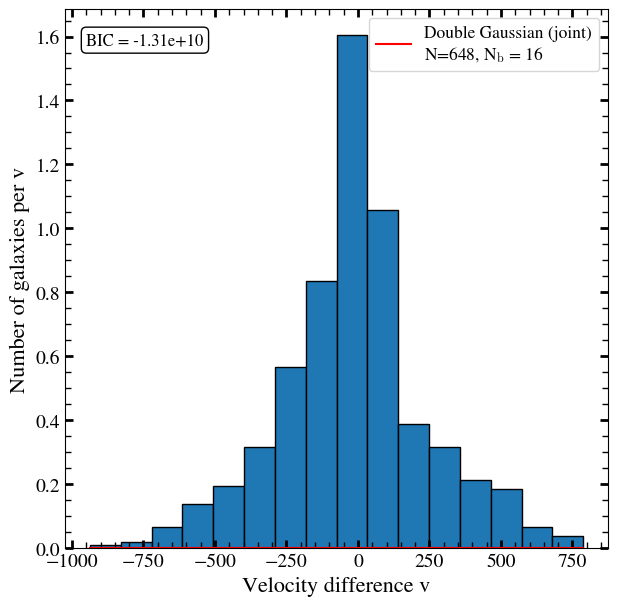

In [ ]:
reload(ONEHALO)

joint_test = ONEHALO.ONEHALO_joint_fitter()
combi_nr = 1 # not an index
test_func_combi = all_combis[combi_nr - 1]
test_func_combi_names = all_names[combi_nr - 1]

init_guess, MCMC_scales = np.load(f'/disks/cosmodm/vdvuurst/data/onehalo_joint_initial_conditions/function_combi_{combi_nr}.npy')
MCMC_scales = MCMC_scales[:, np.newaxis]
simple = _init_conditions(test_func_combi_names)

nwalkers = 50
nsteps = 1000
n_params_r, n_params_m, ntot = joint_fitter.param_info(test_func_combi)

joint_test.fit_function_combi_to_data(test_func_combi, test_func_combi_names, combi_nr, nwalkers, nsteps, verbose = True, plot = True, mbin = [3.0, 3.5], rbin = [0.00, 0.07], show_plot = True)



with open('/disks/cosmodm/vdvuurst/data/OneHalo_param_fits/joint_subsample/function_combi_1') as f:
    param_dict = json.load(f)

n_params_r, n_params_m, ntot = joint_test.param_info(test_func_combi)
params = np.array(param_dict['parameters'])

split_params = joint_test.split_parameters(params, n_params_m)
DG = joint_test.get_double_gauss_parameters(split_params, test_func_combi, n_params_r)
DG

In [21]:
DG

array([[1.49999878e+02, 1.49999985e+02, 1.49999985e+02, ...,
        1.49999985e+02, 1.49999802e+02, 1.49999130e+02],
       [5.00000076e+01, 5.00000000e+01, 5.00000000e+01, ...,
        5.00000000e+01, 5.00000153e+01, 5.00000801e+01],
       [1.08898945e-01, 1.00983299e-01, 1.01355933e-01, ...,
        1.01057082e-01, 1.18975647e-01, 2.07526892e-01]],
      shape=(3, 34447), dtype=float32)

In [11]:
import functions
reload(functions)

with open('/disks/cosmodm/vdvuurst/data/OneHalo_param_fits/joint_subsample/function_combi_1') as f:
    param_dict = json.load(f)

from ONEHALO_initial_conditions import _init_conditions

simple = np.array(_init_conditions(test_func_combi_names))

n_params_r, n_params_m, ntot = joint_test.param_info(test_func_combi)
params = np.array(param_dict['parameters'])

split_params = joint_test.split_parameters(params, n_params_m)
DG = joint_test.get_double_gauss_parameters(split_params, test_func_combi, n_params_r)
sigma1, sigma2, lambda_ = DG

print(DG)

# noise = np.random.normal(0, MCMC_scales, size = (MCMC_scales.size, nwalkers))
# #TODO change back to commented line below
# initial_params = simple[:, np.newaxis] + noise
# # initial_params = init_guess[:, np.newaxis] + noise
# print(' YES', initial_params.shape)

# func=  lambda x: joint_test.get_joint_likelihood(x, *(n_params_m, n_params_r, test_func_combi))
# # np.apply_along_axis(func, 0, initial_params)
# func(initial_params[:,0])

# for pset in initial_params.T:
#     DG = joint_test.get_double_gauss_parameters(split_params, test_func_combi, n_params_r)
#     print(DG)
#     print()
#     print(np.any(~np.isfinite(functions.log_prior_vec(DG))))



[[1.50000046e+02 1.50000000e+02 1.50000000e+02 ... 1.50000000e+02
  1.50000122e+02 1.50000793e+02]
 [5.00000267e+01 5.00000038e+01 5.00000038e+01 ... 5.00000038e+01
  5.00000725e+01 5.00004501e+01]
 [1.18899509e-01 1.02088161e-01 1.02879554e-01 ... 1.02244876e-01
  1.40308321e-01 3.28772128e-01]]


In [16]:

functions.mod_gaussian_log_likelihood_vec(DG, joint_test.min_half_v_sq_arr)
functions.log_prior_vec(DG).nonzero()

(array([], dtype=int64),)

In [17]:
init_guess

array([-2.66367172e-03,  0.00000000e+00, -2.31032067e-03,  0.00000000e+00,
       -2.62540508e-03,  0.00000000e+00, -4.35691478e-03,  1.50000000e+02,
       -2.72565921e-04,  0.00000000e+00, -4.66248848e-04,  5.00000000e+00,
        7.14164337e-01,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        7.14164337e-01,  1.00000000e-01])

In [18]:
MCMC_scales

array([[2.66367172e-04],
       [1.00000000e-04],
       [2.31032067e-04],
       [1.00000000e-04],
       [2.62540508e-04],
       [1.00000000e-04],
       [4.35691478e-04],
       [1.00000000e-04],
       [2.72565921e-05],
       [1.00000000e-04],
       [4.66248848e-05],
       [1.00000000e-04],
       [7.14164337e-02],
       [1.00000000e-04],
       [1.00000000e-04],
       [1.00000000e-04],
       [7.14164337e-02],
       [1.00000000e-04]])

In [19]:
params

array([ 2.00290276e-08, -7.53736164e-09,  1.89155516e-09,  1.30740577e-09,
       -3.41678236e-09, -7.73009784e-09,  2.94172270e-09,  1.50000000e+02,
        2.04802523e-09, -3.51513484e-09,  1.04385668e-09,  5.00000000e+01,
       -4.06685336e-07,  1.81244856e-08,  1.06548038e-08,  2.01020454e-08,
        1.38612151e-06,  9.99999857e-02])